In [1]:
from google.colab import drive

drive.mount("/content/drive")

%cd /content/drive/My Drive/Colab Notebooks

Mounted at /content/drive
/content/drive/My Drive/Colab Notebooks


In [25]:
import torch
import numpy as np

print ("PyTorch Version:",torch.__version__)
# Device configuration
device = torch . device ( 'cuda' if torch.cuda.is_available () else 'cpu')
print("Device:", device)

PyTorch Version: 2.11.0+cu128
Device: cuda


In [3]:
X, Y = np.mgrid[-4.0:4.0:0.01, -4.0:4.0:0.01]

print(X.shape)
print(Y.shape)

(800, 800)
(800, 800)


In [4]:
x = torch.Tensor(X)
y = torch.Tensor(Y)

print(type(X))
print(type(x))

<class 'numpy.ndarray'>
<class 'torch.Tensor'>


In [5]:
x = x.to(device)
y = y.to(device)

print(x.device)
print(y.device)

cuda:0
cuda:0


In [6]:
z = torch.exp(-(x**2 + y**2) / 2.0)

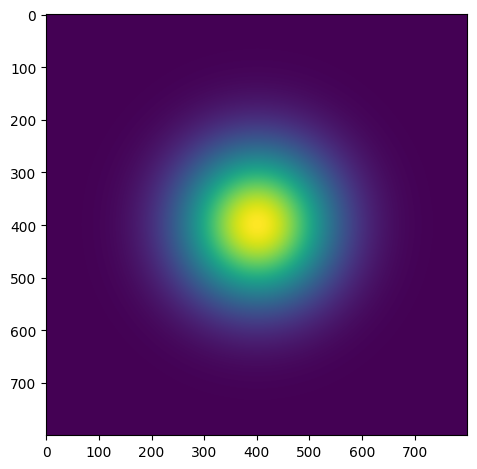

In [7]:
import matplotlib.pyplot as plt

plt.imshow(z.cpu().numpy())
plt.tight_layout()
plt.show()

### Part 1.2 AI Tasks

Prompt 1:
"Generate a Python script to plot a 2D Gaussian function using NumPy and Matplotlib."

Prompt 2:
"Convert the NumPy implementation to PyTorch and use PyTorch tensors.
Run the tensor calculations on the GPU when CUDA is available."

Prompt 3:
"Modify the PyTorch implementation to generate a 2D sine function
and multiply it by the Gaussian function to form a Gabor filter."

The NumPy and PyTorch implementations were very similar because
PyTorch provides tensor operations such as exp(), sin(), and
element-wise multiplication that closely resemble NumPy operations.
The main additional steps in PyTorch were selecting a device,
moving tensors to the GPU, and moving the result back to the CPU
before plotting with Matplotlib.

X shape: (800, 800)
Y shape: (800, 800)


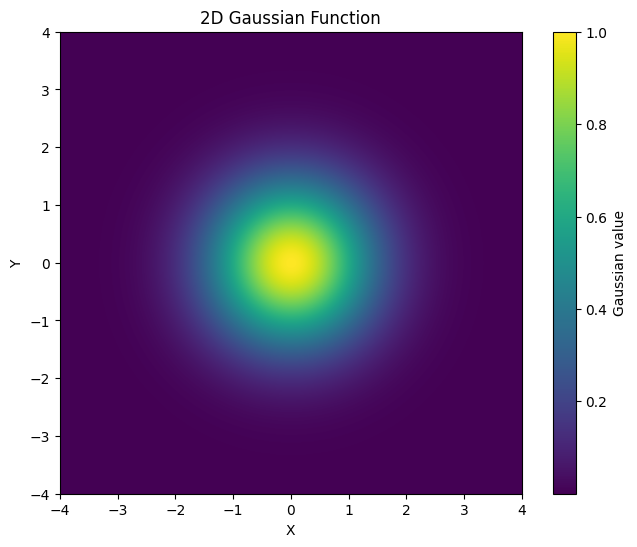

In [8]:
#这个解法是AI生成的
import numpy as np
import matplotlib.pyplot as plt

# 1. Create x and y coordinates
X, Y = np.mgrid[-4.0:4.0:0.01, -4.0:4.0:0.01]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# 2. Define the parameters of the Gaussian
mu_x = 0
mu_y = 0
sigma = 1

# 3. Calculate the 2D Gaussian
Z = np.exp(
    -((X - mu_x)**2 + (Y - mu_y)**2) / (2 * sigma**2)
)

# 4. Plot the Gaussian
plt.figure(figsize=(8, 6))

plt.imshow(
    Z,
    extent=[-4, 4, -4, 4],
    origin="lower",
    cmap="viridis"
)

# 5. Add a color bar
plt.colorbar(label="Gaussian value")

# 6. Add labels and title
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Gaussian Function")

# 7. Display the plot
plt.show()

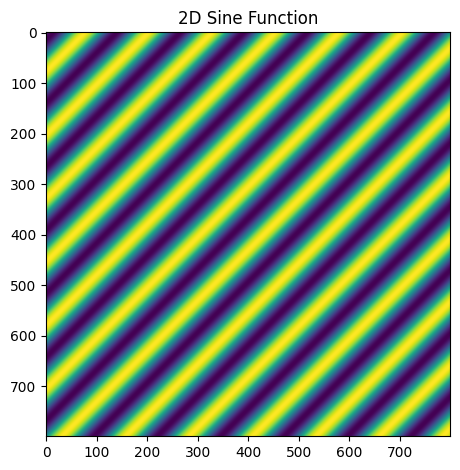

In [9]:
#这个解法也是AI生成的
# Create a 2D sine function
z_sine = torch.sin(5 * (x + y))

# Plot the sine function
import matplotlib.pyplot as plt

plt.imshow(z_sine.cpu().numpy())
plt.title("2D Sine Function")
plt.tight_layout()
plt.show()

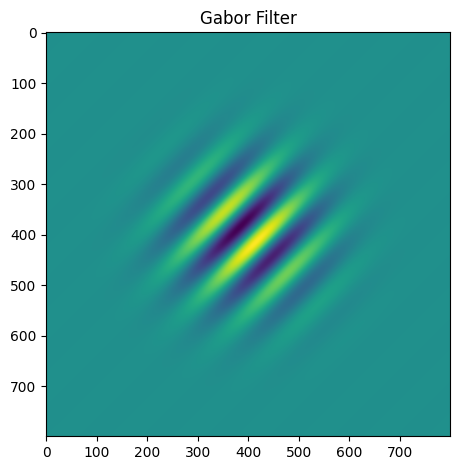

In [10]:
z_gabor = z * z_sine

plt.imshow(z_gabor.cpu().numpy())
plt.title("Gabor Filter")
plt.tight_layout()
plt.show()

In [11]:
#下面开始part2的内容
import torch
import numpy as np

In [12]:
Y, X = np.mgrid[-1.3:1.3:0.005, -2:1:0.005]

print(X.shape)
print(Y.shape)

(520, 600)
(520, 600)


In [13]:
x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)
zs = z.clone()
ns = torch.zeros_like(z)
z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)
print(x.shape)
print(y.shape)
print(z.shape)
print(z[0, 0])

torch.Size([520, 600])
torch.Size([520, 600])
torch.Size([520, 600])
tensor(-2.-1.3000j, device='cuda:0')


In [14]:
print(z.device)
print(zs.device)
print(ns.device)

cuda:0
cuda:0
cuda:0


In [15]:
for i in range(200):
    zs_ = zs * zs + z
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_

In [16]:
import matplotlib . pyplot as plt
fig = plt.figure(figsize =(16 ,10))
def processFractal (a) :
  a_cyclic= (6.28*a/20.0).reshape(list(a.shape)+[1])
  img = np.concatenate ([10+20* np . cos ( a_cyclic ) ,
  30+50*np.sin (a_cyclic) ,
  155 -80* np.cos (a_cyclic)],2)
  img[a==a.max()] = 0
  a = img
  a = np . uint8 ( np . clip (a , 0 , 255) )
  return a

<Figure size 1600x1000 with 0 Axes>

/tmp/ipykernel_1073/2738700647.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


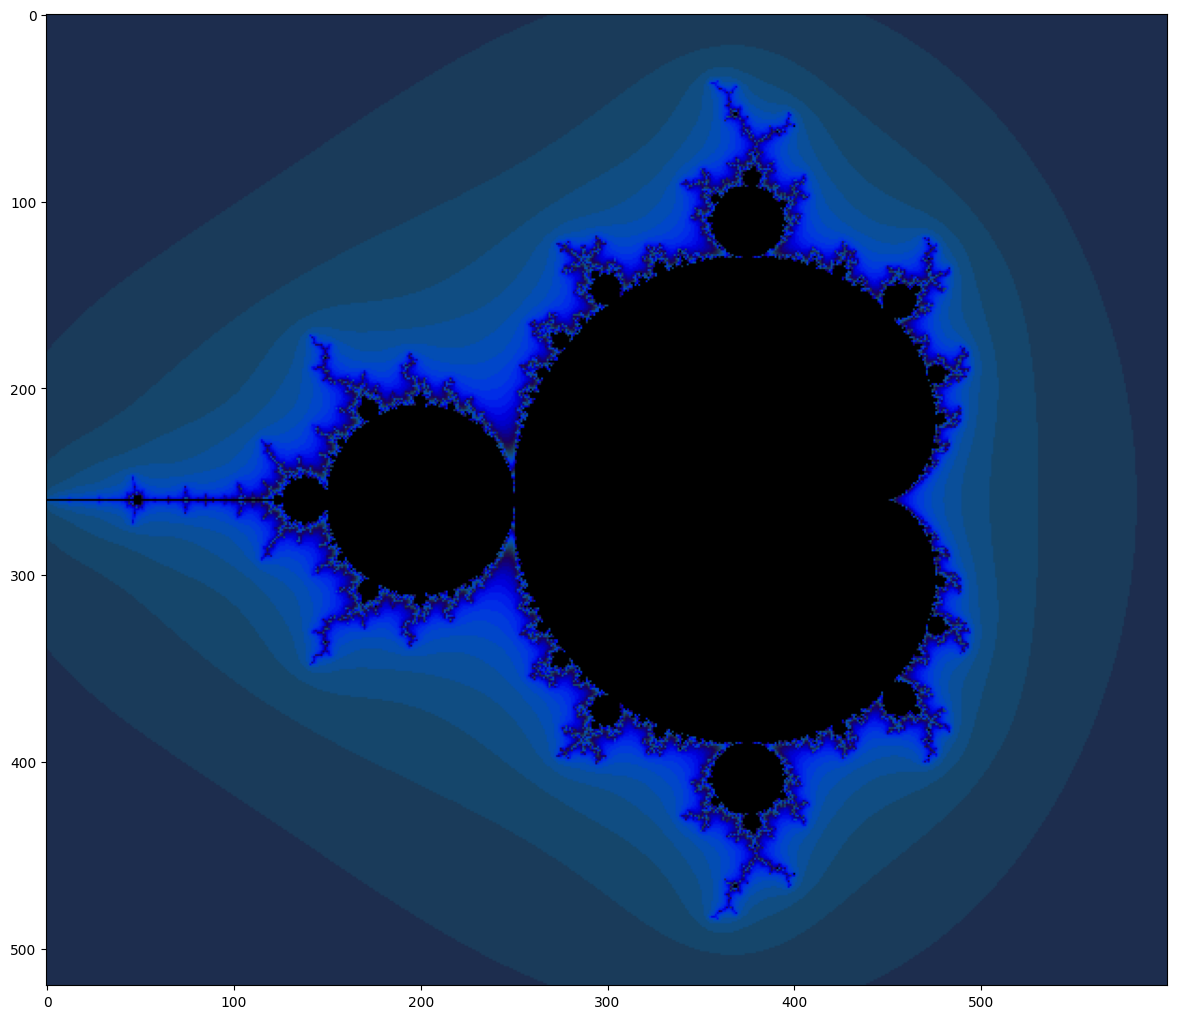

In [17]:
plt.figure(figsize=(16, 10))

plt.imshow(processFractal(ns.cpu().numpy()))

plt.tight_layout(pad=0)
plt.show()

### Part 2.2 AI Task

Prompt:
"Generate a Mandelbrot set implementation using PyTorch. The
computation should run on the GPU when CUDA is available and
Matplotlib should be used to visualise the result."

The AI-generated implementation worked successfully and used
PyTorch tensors on the GPU. The implementation also used an
active mask to keep track of points that had not escaped.

Compared with the implementation in the lab sheet, the AI version
used torch.linspace and torch.meshgrid rather than NumPy mgrid.
It also explicitly stored escape iterations.

Only minor modifications were required to adjust the resolution,
plotting parameters and device handling.

Using device: cuda
GPU: Tesla T4
X shape: torch.Size([800, 1000])
Y shape: torch.Size([800, 1000])


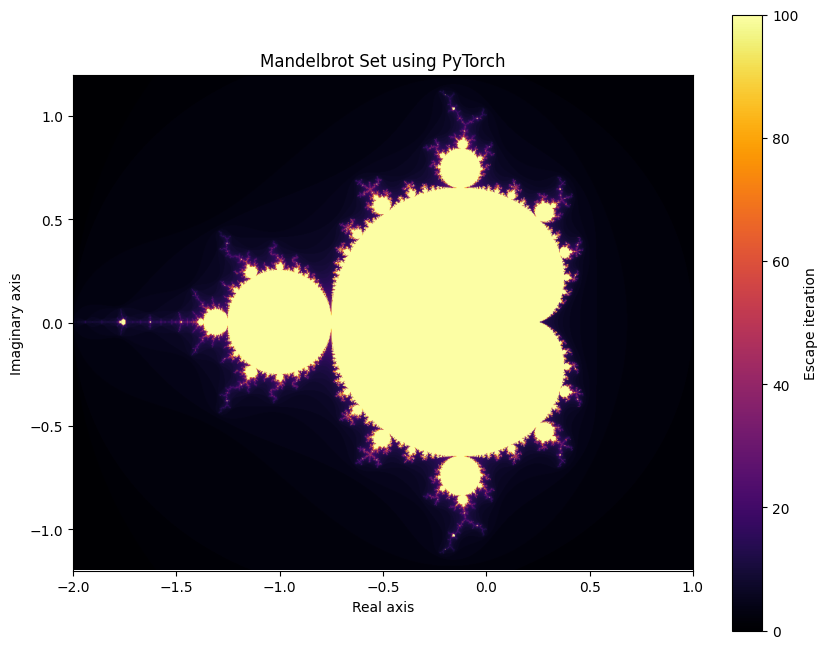

In [18]:
#AI生成的代码
import torch
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. Select device: GPU if CUDA is available
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# --------------------------------------------------
# 2. Mandelbrot settings
# --------------------------------------------------
width = 1000
height = 800
max_iter = 100

x_min, x_max = -2.0, 1.0
y_min, y_max = -1.2, 1.2


# --------------------------------------------------
# 3. Create x and y coordinates using PyTorch
# --------------------------------------------------
x = torch.linspace(x_min, x_max, width, device=device)
y = torch.linspace(y_min, y_max, height, device=device)

X, Y = torch.meshgrid(x, y, indexing="xy")

print("X shape:", X.shape)
print("Y shape:", Y.shape)


# --------------------------------------------------
# 4. Convert each (x, y) coordinate into
#    a complex number c = x + yi
# --------------------------------------------------
C = torch.complex(X, Y)

# Mandelbrot starts with z = 0
Z = torch.zeros_like(C)


# Store the number of iterations before each point escapes
iterations = torch.full(
    C.shape,
    max_iter,
    dtype=torch.int32,
    device=device
)

# True means this point has not escaped yet
active = torch.ones(
    C.shape,
    dtype=torch.bool,
    device=device
)


# --------------------------------------------------
# 5. Mandelbrot iteration
#
#        z(n+1) = z(n)^2 + c
#
#    If |z| > 2, the point escapes.
# --------------------------------------------------
for i in range(max_iter):

    Z = Z * Z + C

    escaped = (torch.abs(Z) > 2.0) & active

    iterations[escaped] = i

    active = active & (~escaped)

    # Stop early if every pixel has escaped
    if not active.any():
        break


# --------------------------------------------------
# 6. Move result from GPU to CPU
#    because Matplotlib uses CPU data
# --------------------------------------------------
mandelbrot = iterations.cpu().numpy()


# --------------------------------------------------
# 7. Visualize the Mandelbrot set
# --------------------------------------------------
plt.figure(figsize=(10, 8))

plt.imshow(
    mandelbrot,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    cmap="inferno"
)

plt.colorbar(label="Escape iteration")

plt.xlabel("Real axis")
plt.ylabel("Imaginary axis")
plt.title("Mandelbrot Set using PyTorch")

plt.show()

(1000, 1000)
(1000, 1000)
torch.Size([1000, 1000])
torch.Size([1000, 1000])
torch.Size([1000, 1000])
tensor(-0.8500+0.0500j, device='cuda:0')
cuda:0
cuda:0
cuda:0


/tmp/ipykernel_1073/482956659.py:37: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


<Figure size 1600x1000 with 0 Axes>

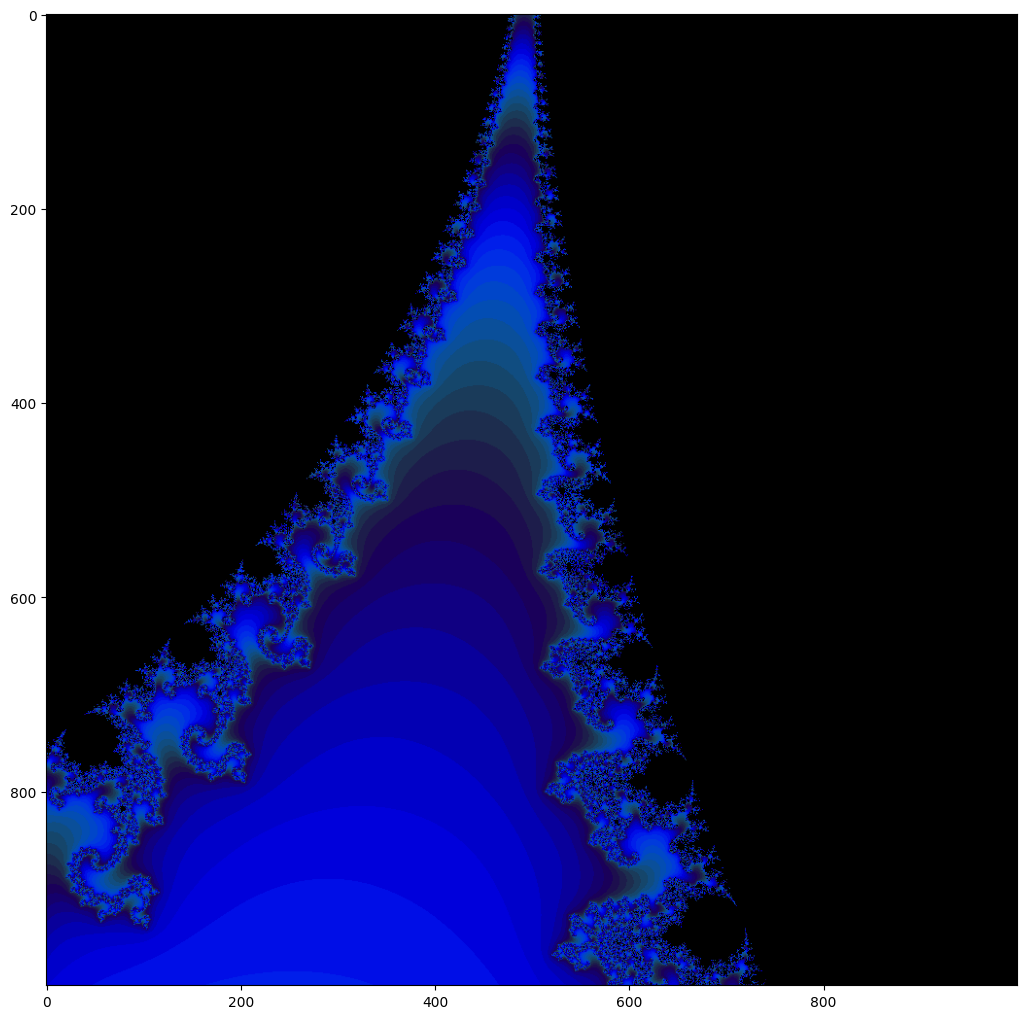

In [19]:
#2.3
import torch
import numpy as np
Y, X = np.mgrid[0.05:0.25:0.0002, -0.85:-0.65:0.0002]

print(X.shape)
print(Y.shape)
x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)
zs = z.clone()
ns = torch.zeros_like(z)
z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)
print(x.shape)
print(y.shape)
print(z.shape)
print(z[0, 0])
print(z.device)
print(zs.device)
print(ns.device)
for i in range(200):
    zs_ = zs * zs + z
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_
import matplotlib . pyplot as plt
fig = plt.figure(figsize =(16 ,10))
def processFractal (a) :
  a_cyclic= (6.28*a/20.0).reshape(list(a.shape)+[1])
  img = np.concatenate ([10+20* np . cos ( a_cyclic ) ,
  30+50*np.sin (a_cyclic) ,
  155 -80* np.cos (a_cyclic)],2)
  img[a==a.max()] = 0
  a = img
  a = np . uint8 ( np . clip (a , 0 , 255) )
  return a
plt.figure(figsize=(16, 10))

plt.imshow(processFractal(ns.cpu().numpy()))

plt.tight_layout(pad=0)
plt.show()

(1000, 1000)
(1000, 1000)
torch.Size([1000, 1000])
torch.Size([1000, 1000])
torch.Size([1000, 1000])
tensor(-1.5000-1.5000j, device='cuda:0')
cuda:0
cuda:0
cuda:0


/tmp/ipykernel_1073/722810838.py:45: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


<Figure size 1600x1000 with 0 Axes>

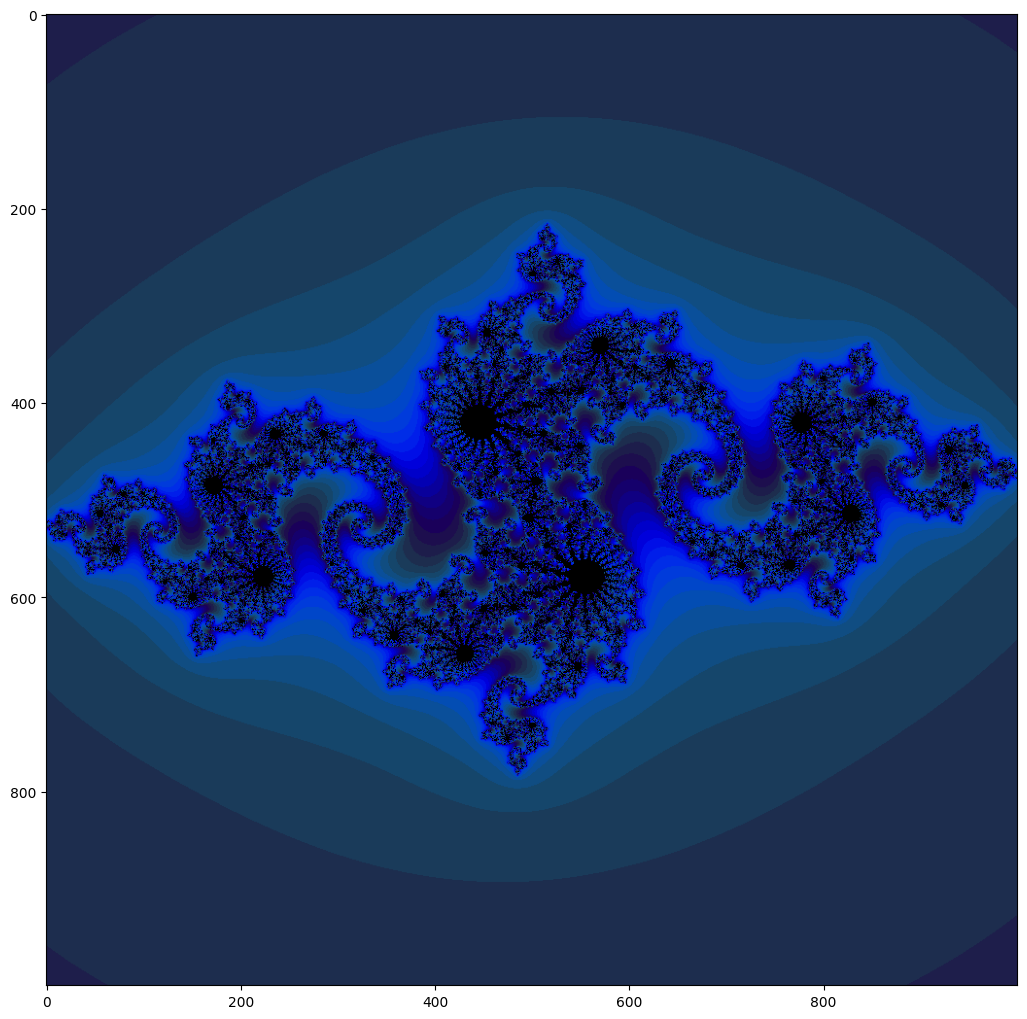

In [20]:
#2.3
import torch
import numpy as np
Y, X = np.mgrid[-1.5:1.5:0.003, -1.5:1.5:0.003] #改

print(X.shape)
print(Y.shape)
x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)
zs = z.clone()
ns = torch.zeros_like(z)
z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)
#改动
c = torch.tensor(
    -0.8 + 0.156j,
    dtype=torch.complex64,
    device=device
)
#
print(x.shape)
print(y.shape)
print(z.shape)
print(z[0, 0])
print(z.device)
print(zs.device)
print(ns.device)
for i in range(200):
    zs_ = zs * zs + c #改

    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_
import matplotlib . pyplot as plt
fig = plt.figure(figsize =(16 ,10))
def processFractal (a) :
  a_cyclic= (6.28*a/20.0).reshape(list(a.shape)+[1])
  img = np.concatenate ([10+20* np . cos ( a_cyclic ) ,
  30+50*np.sin (a_cyclic) ,
  155 -80* np.cos (a_cyclic)],2)
  img[a==a.max()] = 0
  a = img
  a = np . uint8 ( np . clip (a , 0 , 255) )
  return a
plt.figure(figsize=(16, 10))

plt.imshow(processFractal(ns.cpu().numpy()))

plt.tight_layout(pad=0)
plt.show()

In [24]:
fractal_dimension = math.log(3) / math.log(2)

print(
    "Theoretical fractal dimension:",
    fractal_dimension
)

Theoretical fractal dimension: 1.5849625007211563


### Fractal Analysis

The Sierpinski gasket is self-similar. Each iteration produces
three copies of the previous structure, with each copy scaled by
a factor of 1/2.

Therefore its fractal dimension is

D = log(3) / log(2) ≈ 1.585.

This dimension is between 1 and 2, meaning that the Sierpinski
gasket is more complex than a one-dimensional curve but does not
completely fill a two-dimensional area.

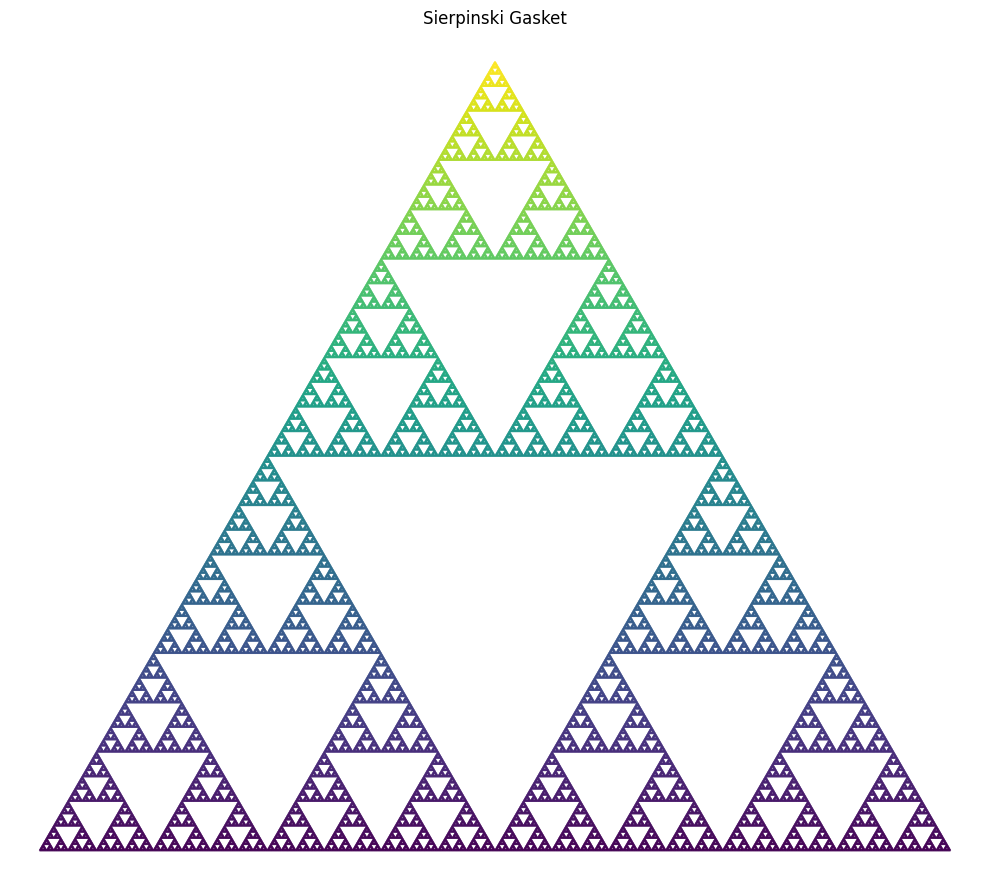

Device: cuda
Number of points: 177147


In [21]:
import math
import torch
import matplotlib.pyplot as plt


# Use GPU when CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Three vertices of an equilateral triangle
vertices = torch.tensor(
    [
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, math.sqrt(3) / 2]
    ],
    dtype=torch.float32,
    device=device
)

# Begin at the centre of the triangle
points = vertices.mean(dim=0, keepdim=True)

iterations = 11

# At each iteration, create three half-sized copies
for _ in range(iterations):
    points = (
        (points[:, None, :] + vertices[None, :, :]) / 2
    ).reshape(-1, 2)

# Move the final result to CPU for Matplotlib
points = points.cpu().numpy()

plt.figure(figsize=(10, 9))

plt.scatter(
    points[:, 0],
    points[:, 1],
    s=0.15,
    c=points[:, 1],
    cmap="viridis",
    marker="."
)

plt.title("Sierpinski Gasket")
plt.axis("equal")
plt.axis("off")
plt.tight_layout()

plt.savefig(
    "sierpinski_gasket.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Device:", device)
print("Number of points:", len(points))